# Baseline Model Tests
Here we run the following models

* Decision Tree Classifier
* XGboost Classifier

before feature engineering. This is to get a sense of what the features we already have tell us.

## **1. Unit of Analysis**

Each row in the dataset represents a **station-hour observation** that merges:
- Meteorological readings from a weather `val_radius` kilometers away (there may be more than one station).
- Tornado occurrence metadata (begin/end latitudes, longitudes, time).

Our prediction target is a Boolean variable:
> `TORNADO_OCCURRENCE ∈ {0, 1}` — whether a tornado was active near the station within the prior `time_window` hours.


In [1]:
## Setup
import pandas as pd
import numpy as np
import os
import math
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import itertools
import sys
import pathlib
import datetime as dt
import notebook_file_utilities.auto_add_project_root as proroot

# For reading in modules from src and reading/saving files
project_root = proroot.auto_add_project_root()

from src.pipeline.preprocessing import preprocessing
from src.pipeline.feature_engineering import Pre_Train_Test_Split_FE
from src.pipeline.drop_cols import (
    pre_split_drop,
    post_split_drop
)
from src.cleaning.merged_tornado_indicator import create_tornado_indicator
import src.cleaning.na_imputer as na_imp
import src.cleaning.drop_features as dfeat
import Data.metadata.cleaned_feature_info as featinfo


In [2]:
# Read in data
data = create_tornado_indicator(time_window=1,val_radius=50)

/Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/src/cleaning/clean_stations.py:93: DtypeWarning: Columns (7,14,15,16,17,19,20,21,22,23,24,25,26,27,28,29,30,32,33,34,40,41,42,43,44,45,46,47,50,51,52,56,57,58,59,60,65,68,69,70,71,76,79,80,81,82,83,90,91,92,93,94,95,96,97,98,99,102,104,105,106,110,111,113,120,121,122,125) have mixed types. Specify dtype option on import or set low_memory=False.
  station_dfs=[pd.read_csv(os.path.join(station_dir,file)).copy() for file in station_csv_files]
/Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/src/cleaning/clean_stations.py:93: DtypeWarning: Columns (39,40,41,42,43,47,48,52,53,54,55,57,58,59,60,61,65,70,71,76,77,88,89,106,108,109,110) have mixed types. Specify dtype option on import or set low_memory=False.
  station_dfs=[pd.read_csv(os.path.join(station_dir,file)).copy() for file in station_csv_files]
/Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/src/cleaning/clean_stations.py:93: Dt

In [3]:
# Preprocess Pipeline
data = preprocessing.fit_transform(data)

In [4]:
# Pre Split Column Drop
data = pre_split_drop.fit_transform(data)

In [5]:
# Pre Split Feature Engineering

data = Pre_Train_Test_Split_FE.fit_transform(data)

In [6]:
# Split
# Hold data from years 2019-2021 aside for test data
# Years 2000-2018 for train

data_train = data[data['year']<=2017]
data_test = data[data['year']> 2017]


In [7]:
X_train = data_train.drop(columns = 'TORNADO_OCCURRENCE')
y_train = data_train['TORNADO_OCCURRENCE']
X_test = data_test.drop(columns = 'TORNADO_OCCURRENCE')
y_test = data_test['TORNADO_OCCURRENCE']

In [8]:
print("Train years:", sorted(data_train['year'].unique()))
print("Test years:", sorted(data_test['year'].unique()))
print("Train tornado ratio:", y_train.mean().round(4))
print("Test tornado ratio:", y_test.mean().round(4))
print("Train-Test Ratio:", len(X_train)/len(data), len(X_test)/len(data) )

# tornado ratio is lower in train than test


Train years: [np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
Test years: [np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]
Train tornado ratio: 0.0081
Test tornado ratio: 0.0124
Train-Test Ratio: 0.7623997968732997 0.23760020312670027


In [9]:
# Post Train-Test Split Column Drop

X_train = post_split_drop.fit_transform(X_train)
X_test = post_split_drop.fit_transform(X_test)


Decision Tree Results:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99    129380
        True       0.00      0.00      0.00      1628

    accuracy                           0.99    131008
   macro avg       0.49      0.50      0.50    131008
weighted avg       0.98      0.99      0.98    131008

ROC-AUC: 0.49952465605194
Average Precision Score: 0.012426722032242305


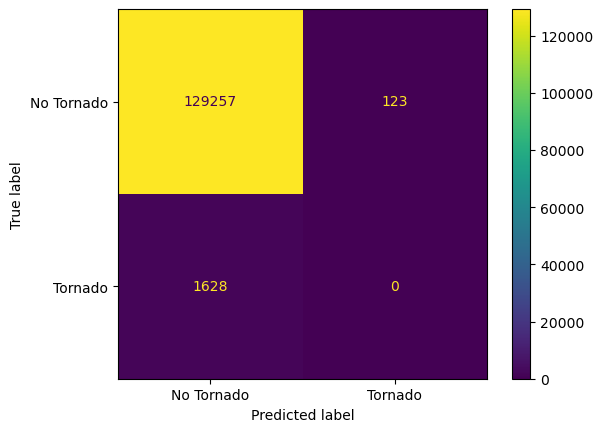

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [17:29:52] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744329023465/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Results:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99    129380
        True       0.00      0.00      0.00      1628

    accuracy                           0.99    131008
   macro avg       0.49      0.50      0.50    131008
weighted avg       0.98      0.99      0.98    131008

ROC-AUC: 0.5
Average Precision Score: 0.012426722032242305


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

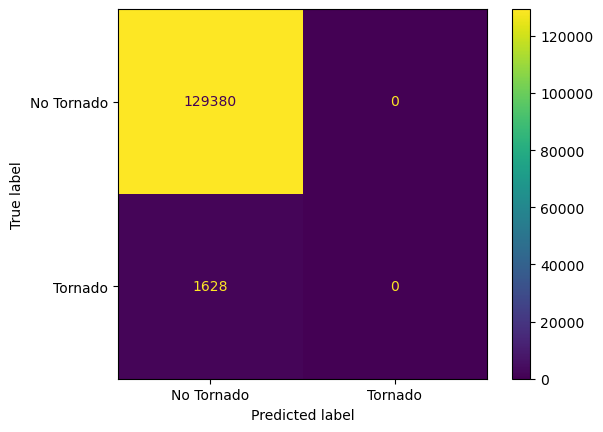

In [25]:
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, 
                            roc_auc_score,
                            confusion_matrix,
                            average_precision_score,
                            precision_recall_curve,
                            ConfusionMatrixDisplay)

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"\n{name} Results:")
    print(classification_report(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, preds))
    print("Average Precision Score:", average_precision_score(y_test, preds))
    precision_recall_curve(y_test, preds)
    cm=confusion_matrix(y_test, preds,labels =[False, True])
    cmd = ConfusionMatrixDisplay(cm,display_labels=['No Tornado', 'Tornado'])

    cmd.plot()
    plt.show()





/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [19:25:10] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744329023465/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

       False       0.99      1.00      0.99    129380
        True       0.00      0.00      0.00      1628

    accuracy                           0.99    131008
   macro avg       0.49      0.50      0.50    131008
weighted avg       0.98      0.99      0.98    131008

ROC-AUC: 0.8120398247852258
Average Precision Score: 0.04579022238005088


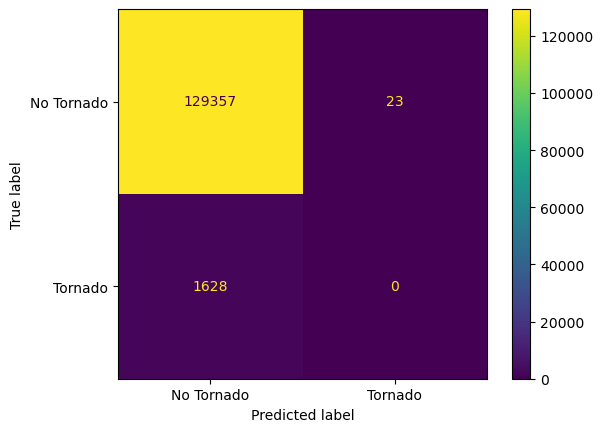

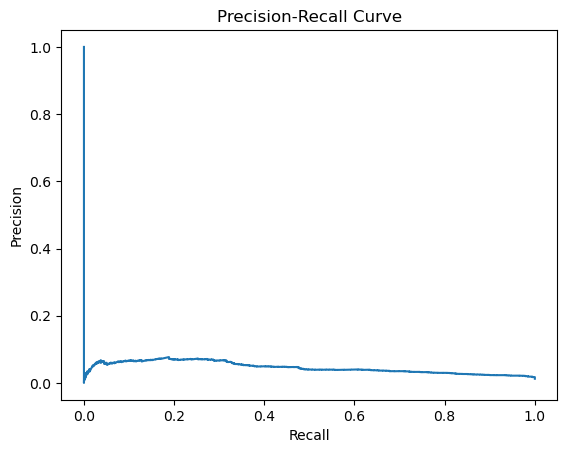

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight
)
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.1).astype(int)
print(classification_report(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))
print("Average Precision Score:", average_precision_score(y_test, probs))
cm=confusion_matrix(y_test, preds,labels =[False, True])
cmd = ConfusionMatrixDisplay(cm,display_labels=['No Tornado', 'Tornado'])

cmd.plot()
plt.show()

precisions,recalls,thresholds=precision_recall_curve(y_test,probs)

plt.plot(recalls,precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [17:37:12] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744329023465/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

       False       0.99      1.00      0.99    129380
        True       0.01      0.00      0.00      1628

    accuracy                           0.99    131008
   macro avg       0.50      0.50      0.50    131008
weighted avg       0.98      0.99      0.98    131008

ROC-AUC: 0.4999554480772598
Average Precision Score: 0.0124257655477123


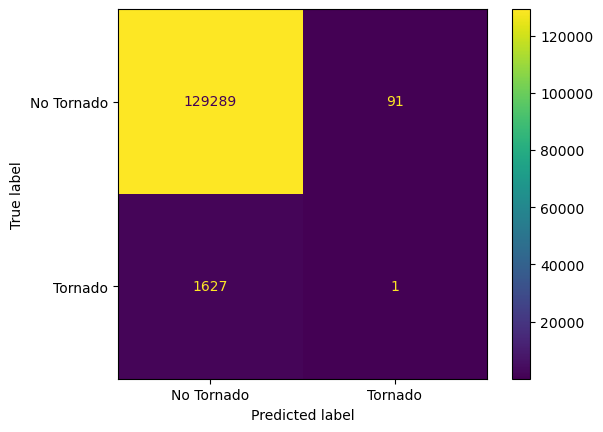

In [ ]:
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight
)
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.05).astype(int)
print(classification_report(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, preds))
print("Average Precision Score:", average_precision_score(y_test, preds))
cm=confusion_matrix(y_test, preds,labels =[False, True])
cmd = ConfusionMatrixDisplay(cm,display_labels=['No Tornado', 'Tornado'])

cmd.plot()


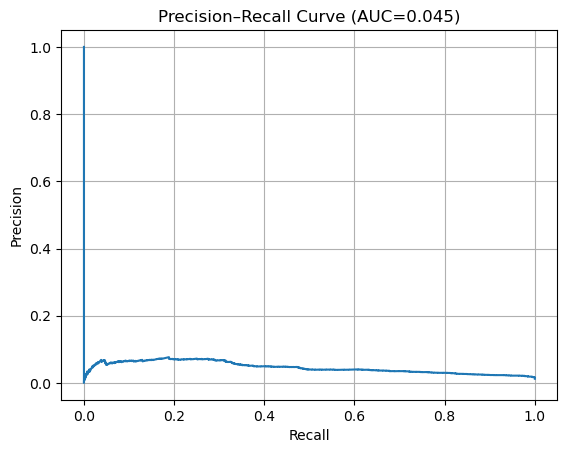

Threshold for ~0.6 recall: 3.575998334781616e-06


In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, probs)
pr_auc = auc(recall, precision)

plt.plot(recall, precision)
plt.title(f'Precision–Recall Curve (AUC={pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

# Example: pick threshold that gives recall ≈ 0.6
target_recall = 0.6
i = np.argmin(np.abs(recall - target_recall))
best_thresh = thresholds[i]
print(f"Threshold for ~{target_recall:.1f} recall: {best_thresh}")
